In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("data/all_data_merged.csv", parse_dates=["DATE"])
df = df.sort_values(["DISTRICT", "DATE"]).reset_index(drop=True)

ohe = OneHotEncoder(sparse_output=False)
district_onehot = ohe.fit_transform(df[["DISTRICT"]])

X_base = df[["WEATHER_CONDITION","SPECIAL_DAY","DAY_OF_WEEK_NUM",
             "POPULATION","RAILWAY_STATIONS","BUS_STATIONS"]].values
X_raw = np.hstack([X_base, district_onehot])
y_raw = df["CONGESTION"].values.reshape(-1, 1)

sx, sy = MinMaxScaler(), MinMaxScaler()
Xs = sx.fit_transform(X_raw)
ys = sy.fit_transform(y_raw)

seq_len = 10
Xs_seq, ys_seq, districts_seq = [], [], []
for i in range(len(Xs) - seq_len):
    Xs_seq.append(Xs[i:i+seq_len])
    ys_seq.append(ys[i+seq_len])
    districts_seq.append(df["DISTRICT"].iloc[i+seq_len])
Xs_seq, ys_seq, districts_seq = np.array(Xs_seq), np.array(ys_seq), np.array(districts_seq)

In [3]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_dim=32, n_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, n_layers, batch_first=True)
        self.out = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        h, _ = self.lstm(x)
        return self.out(h[:, -1, :])

n_features = Xs_seq.shape[-1]
model = LSTMRegressor(n_features=n_features, hidden_dim=32, n_layers=1)

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

batch_size = 128
X_train = torch.tensor(Xs_seq, dtype=torch.float32)
y_train = torch.tensor(ys_seq, dtype=torch.float32)

train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
n_epochs = 20

model.train()
for epoch in range(n_epochs):
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = criterion(preds, yb.squeeze())
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)
    avg_loss = total_loss / len(X_train)
    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {avg_loss:.5f}")

Epoch 1/20 - Train Loss: 0.01894
Epoch 2/20 - Train Loss: 0.00470
Epoch 3/20 - Train Loss: 0.00466
Epoch 4/20 - Train Loss: 0.00464
Epoch 5/20 - Train Loss: 0.00455
Epoch 6/20 - Train Loss: 0.00437
Epoch 7/20 - Train Loss: 0.00423
Epoch 8/20 - Train Loss: 0.00405
Epoch 9/20 - Train Loss: 0.00363
Epoch 10/20 - Train Loss: 0.00311
Epoch 11/20 - Train Loss: 0.00273
Epoch 12/20 - Train Loss: 0.00280
Epoch 13/20 - Train Loss: 0.00256
Epoch 14/20 - Train Loss: 0.00238
Epoch 15/20 - Train Loss: 0.00224
Epoch 16/20 - Train Loss: 0.00221
Epoch 17/20 - Train Loss: 0.00197
Epoch 18/20 - Train Loss: 0.00186
Epoch 19/20 - Train Loss: 0.00179
Epoch 20/20 - Train Loss: 0.00173


District 1: MSE=0.00, MAE=0.01, Predicted std: 0.02, True std: 0.03


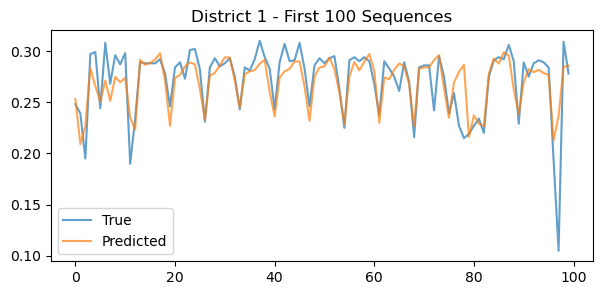

District 2: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.06


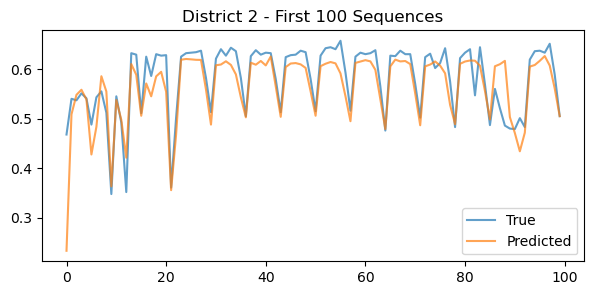

District 3: MSE=0.00, MAE=0.02, Predicted std: 0.06, True std: 0.07


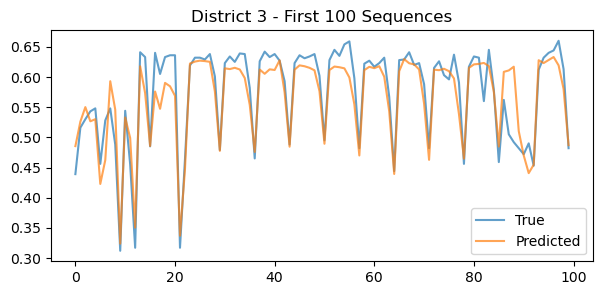

District 4: MSE=0.00, MAE=0.03, Predicted std: 0.06, True std: 0.07


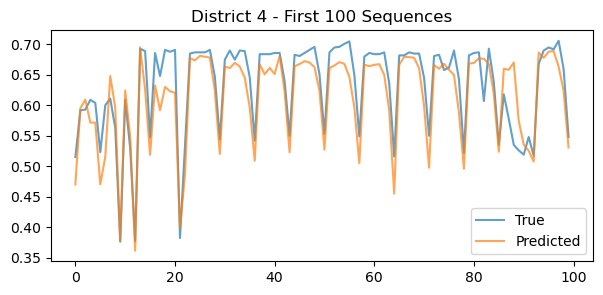

District 5: MSE=0.00, MAE=0.03, Predicted std: 0.06, True std: 0.07


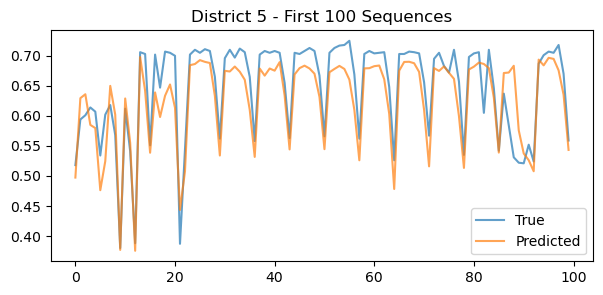

District 6: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


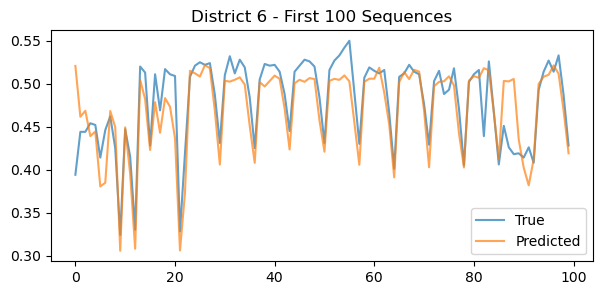

District 7: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


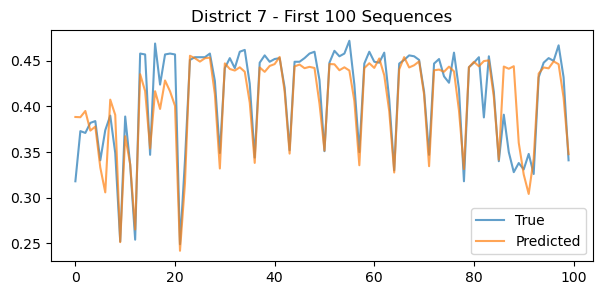

District 8: MSE=0.00, MAE=0.03, Predicted std: 0.07, True std: 0.08


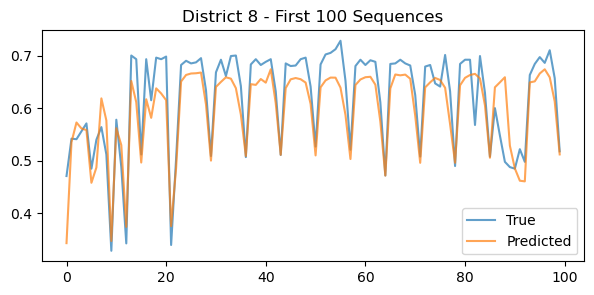

District 9: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.06


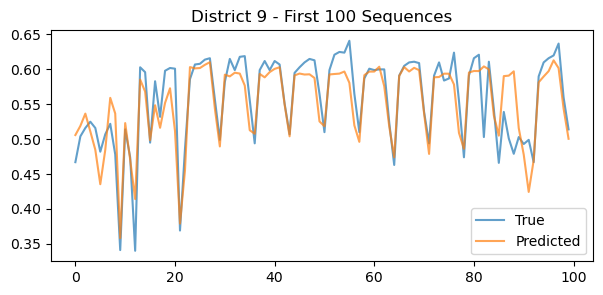

District 10: MSE=0.00, MAE=0.02, Predicted std: 0.03, True std: 0.03


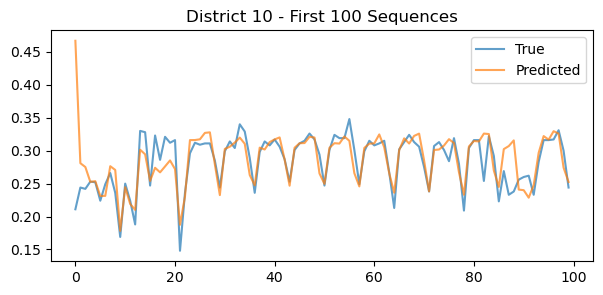

District 11: MSE=0.00, MAE=0.02, Predicted std: 0.06, True std: 0.06


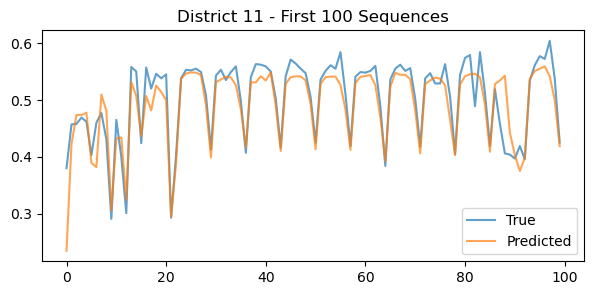

District 12: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


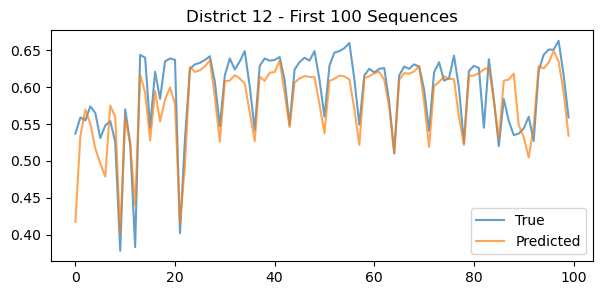

District 13: MSE=0.00, MAE=0.01, Predicted std: 0.02, True std: 0.02


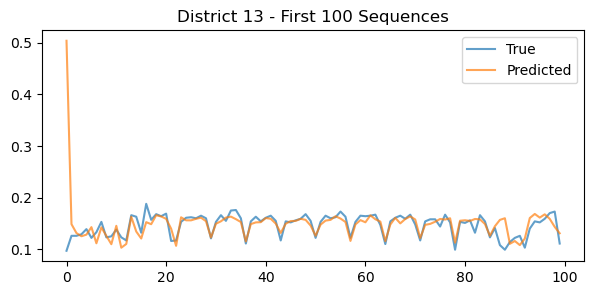

District 15: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.06


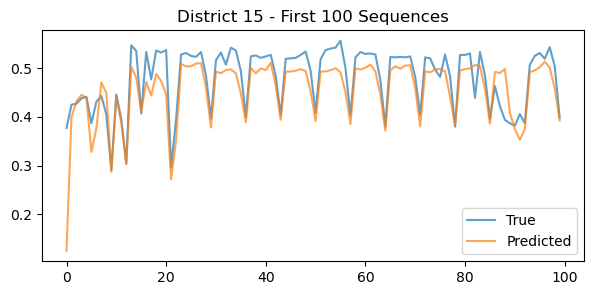

District 16: MSE=0.00, MAE=0.03, Predicted std: 0.07, True std: 0.08


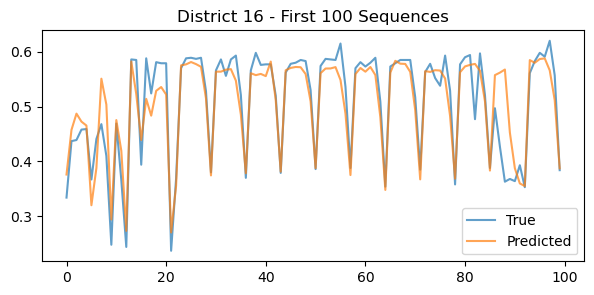

District 17: MSE=0.00, MAE=0.02, Predicted std: 0.03, True std: 0.04


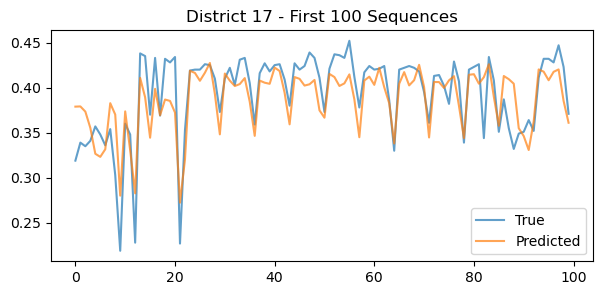

District 18: MSE=0.00, MAE=0.02, Predicted std: 0.03, True std: 0.04


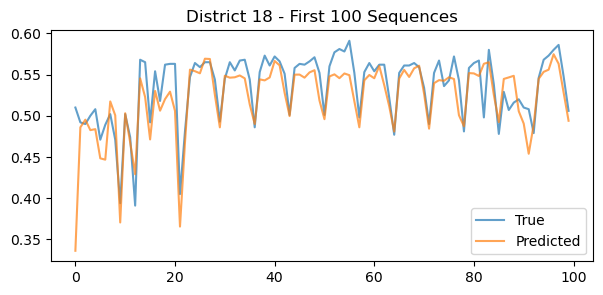

District 19: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


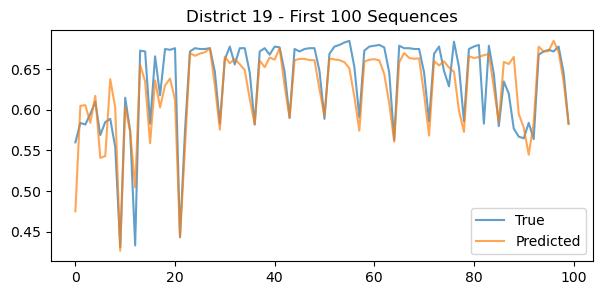

District 20: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.05


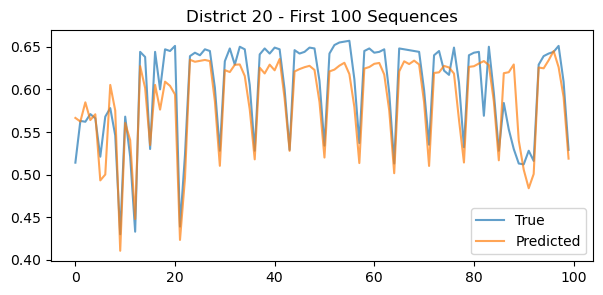

District 21: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


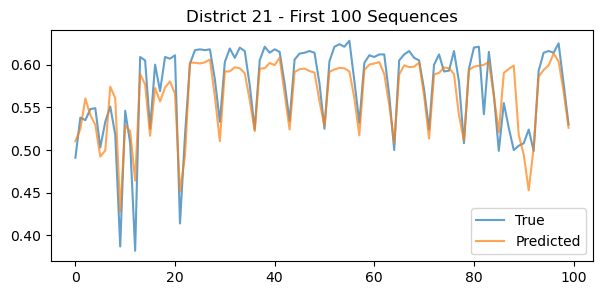

District 22: MSE=0.00, MAE=0.03, Predicted std: 0.06, True std: 0.07


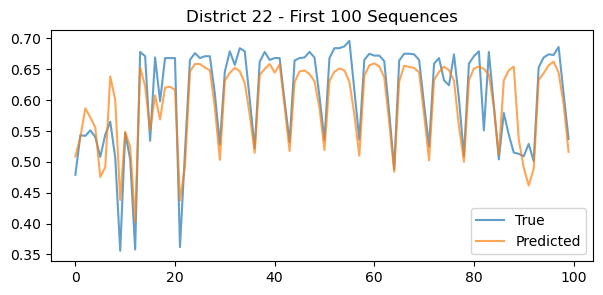

District 23: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


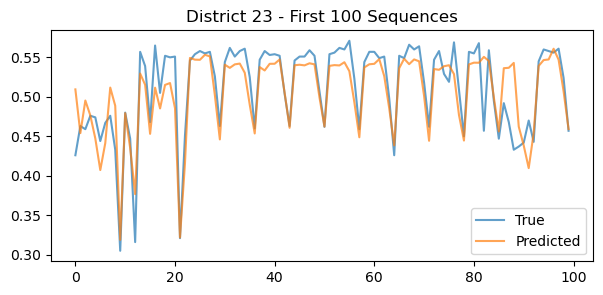

District 24: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


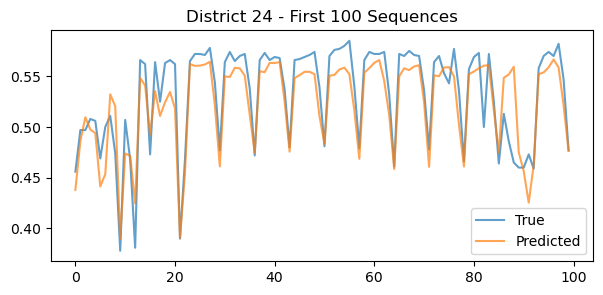

District 25: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


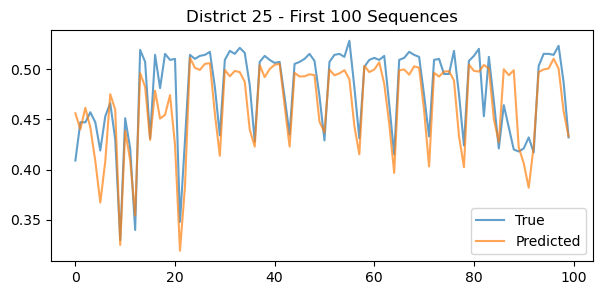

District 26: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.05


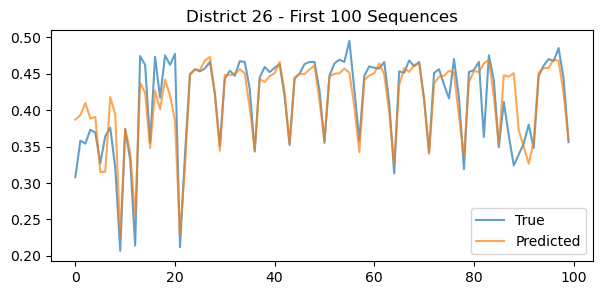

District 27: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.06


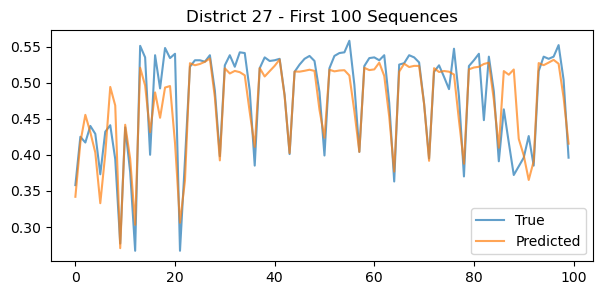

District 28: MSE=0.00, MAE=0.01, Predicted std: 0.03, True std: 0.03


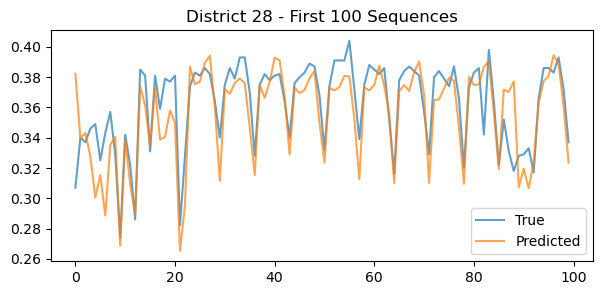

District 29: MSE=0.00, MAE=0.01, Predicted std: 0.01, True std: 0.02


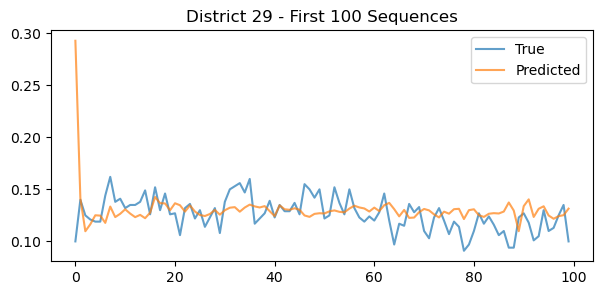

District 30: MSE=0.00, MAE=0.03, Predicted std: 0.06, True std: 0.06


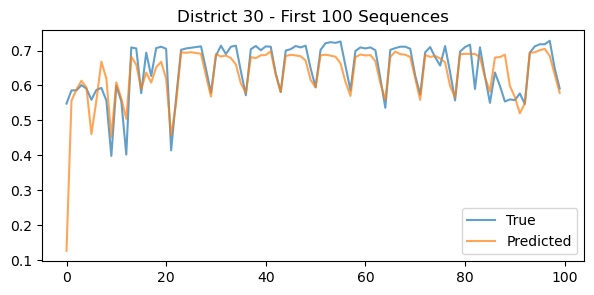

District 31: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


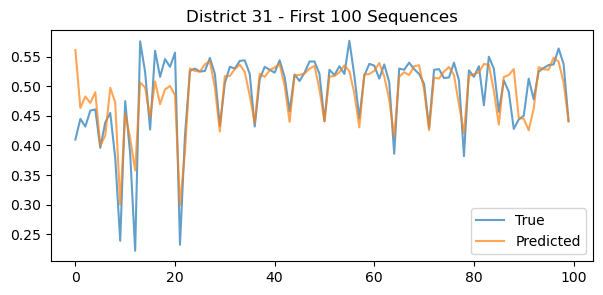

District 32: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


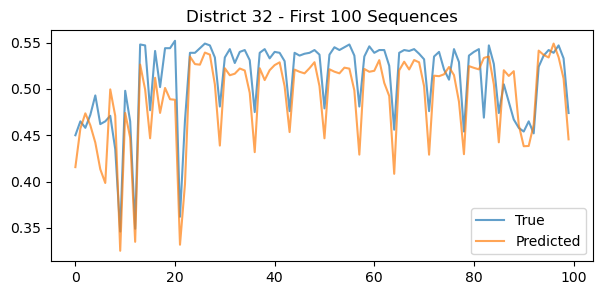

District 33: MSE=0.00, MAE=0.02, Predicted std: 0.05, True std: 0.05


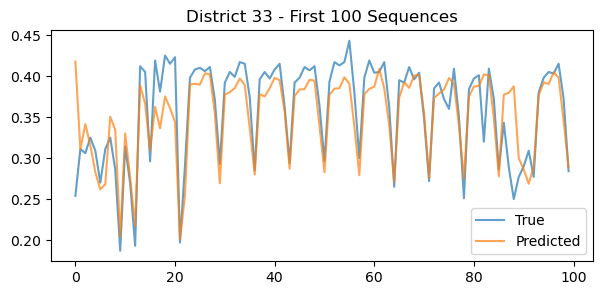

District 34: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.05


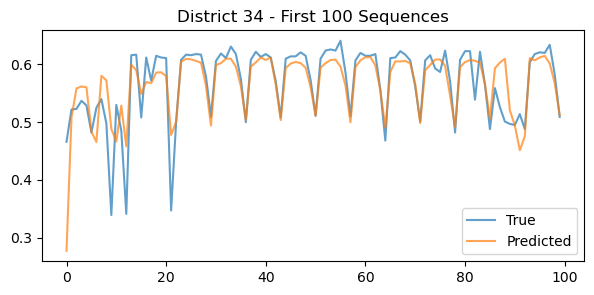

District 35: MSE=0.00, MAE=0.02, Predicted std: 0.03, True std: 0.04


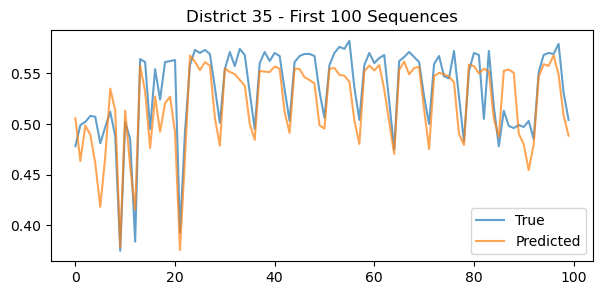

District 36: MSE=0.00, MAE=0.03, Predicted std: 0.06, True std: 0.06


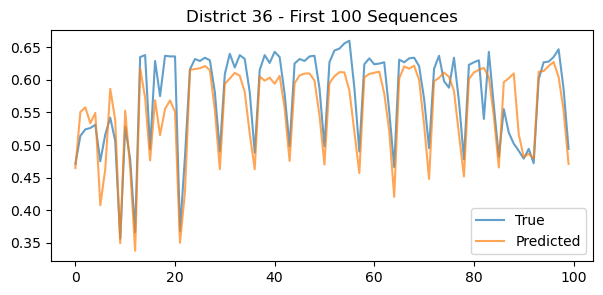

District 37: MSE=0.00, MAE=0.01, Predicted std: 0.02, True std: 0.02


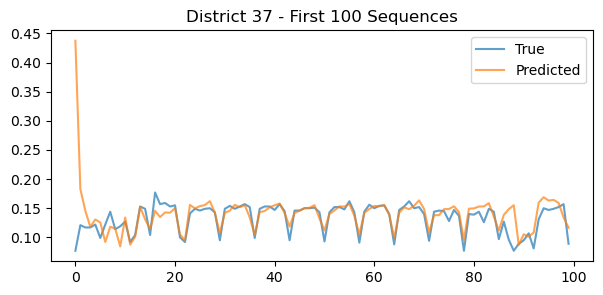

District 38: MSE=0.00, MAE=0.02, Predicted std: 0.04, True std: 0.04


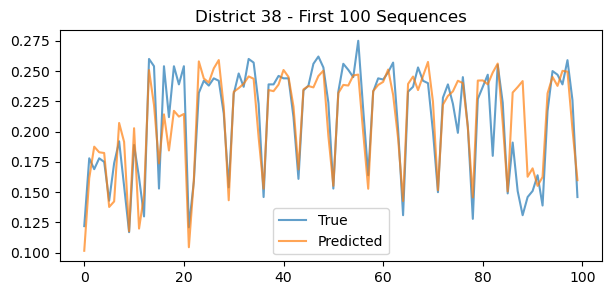

In [5]:
model.eval()
districts = np.unique(districts_seq)

for district in districts:
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]

    if len(X_d) == 0:
        continue

    Xb = torch.tensor(X_d, dtype=torch.float32).to(device)
    with torch.no_grad():
        preds = model(Xb).cpu().squeeze().numpy()
    preds_inv = sy.inverse_transform(preds.reshape(-1,1))
    y_true_inv = sy.inverse_transform(y_d.reshape(-1,1))

    mse = mean_squared_error(y_true_inv, preds_inv)
    mae = mean_absolute_error(y_true_inv, preds_inv)
    std_pred = preds_inv.std()
    std_true = y_true_inv.std()

    print(f"District {district}: MSE={mse:.2f}, MAE={mae:.2f}, Predicted std: {std_pred:.2f}, True std: {std_true:.2f}")

    plt.figure(figsize=(7,3))
    plt.plot(y_true_inv[:100], label="True", alpha=0.7)
    plt.plot(preds_inv[:100], label="Predicted", alpha=0.7)
    plt.title(f"District {district} - First 100 Sequences")
    plt.legend()
    plt.show()

In [6]:
results = []
for district in districts:
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]

    if len(X_d) == 0:
        continue

    Xb = torch.tensor(X_d, dtype=torch.float32)
    with torch.no_grad():
        preds = model(Xb).squeeze().numpy()
    preds_inv = sy.inverse_transform(preds.reshape(-1,1))
    y_true_inv = sy.inverse_transform(y_d.reshape(-1,1))

    mse = mean_squared_error(y_true_inv, preds_inv)
    mae = mean_absolute_error(y_true_inv, preds_inv)
    std_pred = preds_inv.std()
    std_true = y_true_inv.std()

    results.append({"District": district, "MSE": mse, "MAE": mae, 
                    "Predicted Std": std_pred, "Real Std": std_true})

df_results = pd.DataFrame(results)
print(df_results.sort_values("MSE"))

    District       MSE       MAE  Predicted Std  Real Std
0          1  0.000305  0.011558       0.021590  0.027078
26        28  0.000361  0.013935       0.026136  0.026401
27        29  0.000393  0.012579       0.010794  0.015679
36        38  0.000454  0.015223       0.036546  0.040346
19        21  0.000504  0.017469       0.035881  0.043328
23        25  0.000517  0.018313       0.036251  0.037417
22        24  0.000531  0.017277       0.037033  0.043837
33        35  0.000540  0.019037       0.034780  0.035895
18        20  0.000556  0.018630       0.045929  0.049718
35        37  0.000600  0.011861       0.024879  0.022708
9         10  0.000606  0.015588       0.032875  0.034751
16        18  0.000609  0.018835       0.033693  0.035542
5          6  0.000636  0.019548       0.042707  0.044477
12        13  0.000650  0.011018       0.024954  0.018676
30        32  0.000659  0.019164       0.038660  0.039388
6          7  0.000680  0.016284       0.043612  0.051152
21        23  

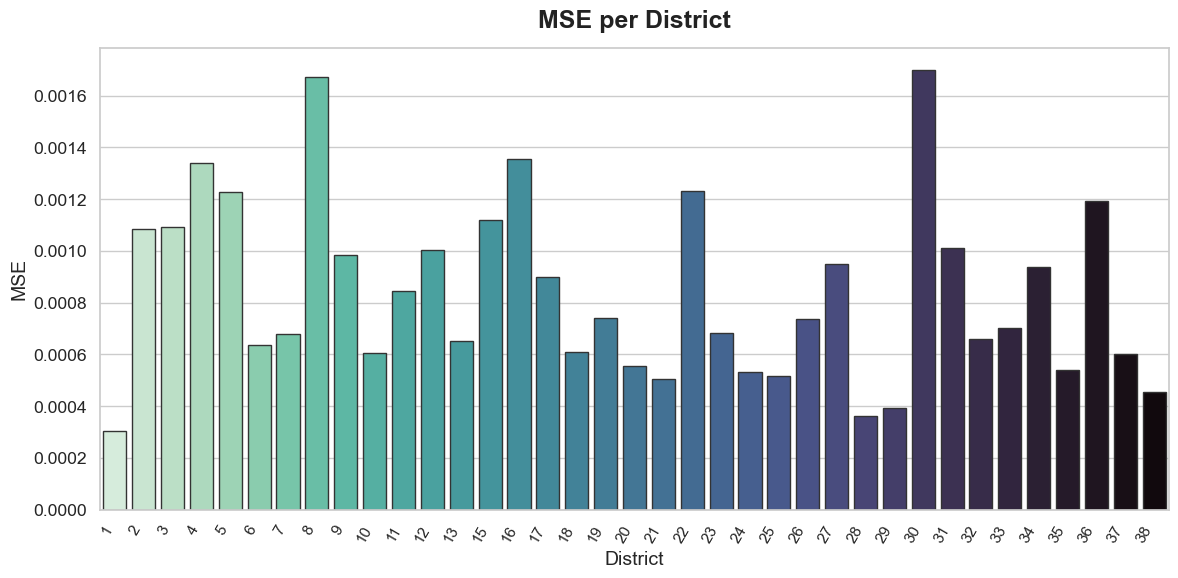

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)

plt.figure(figsize=(12, 6))
sorted_df = df_results.sort_values("MSE")
bar = sns.barplot(x="District", y="MSE", data=sorted_df, palette="mako_r", edgecolor=".2")
plt.title("MSE per District", weight="bold", fontsize=18, color="#222222", pad=15)
plt.ylabel("MSE", fontsize=14)
plt.xlabel("District", fontsize=14)
plt.xticks(rotation=60, ha="right", fontsize=11)
plt.tight_layout()
plt.show()


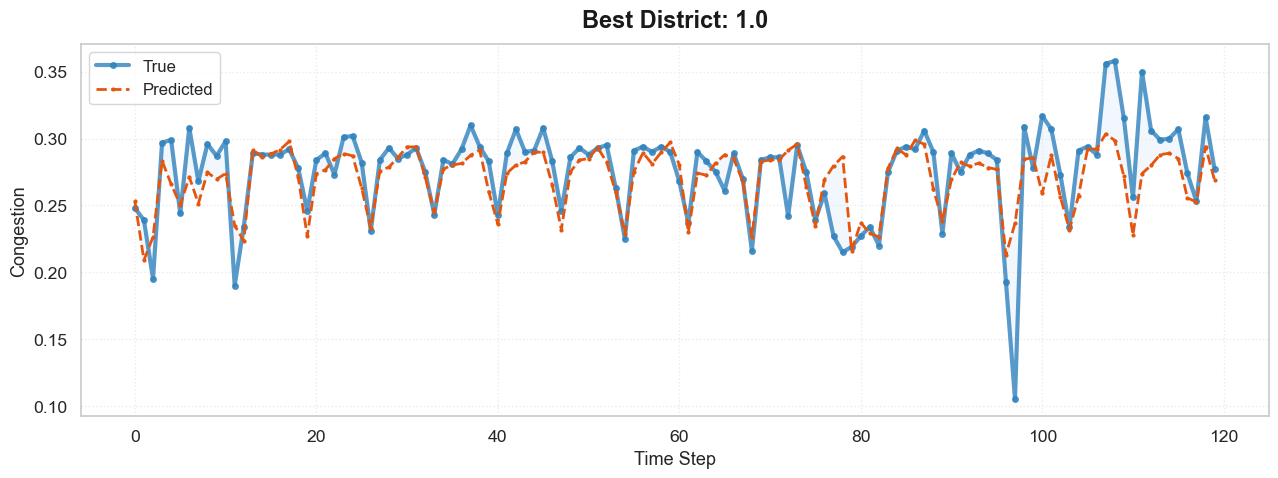

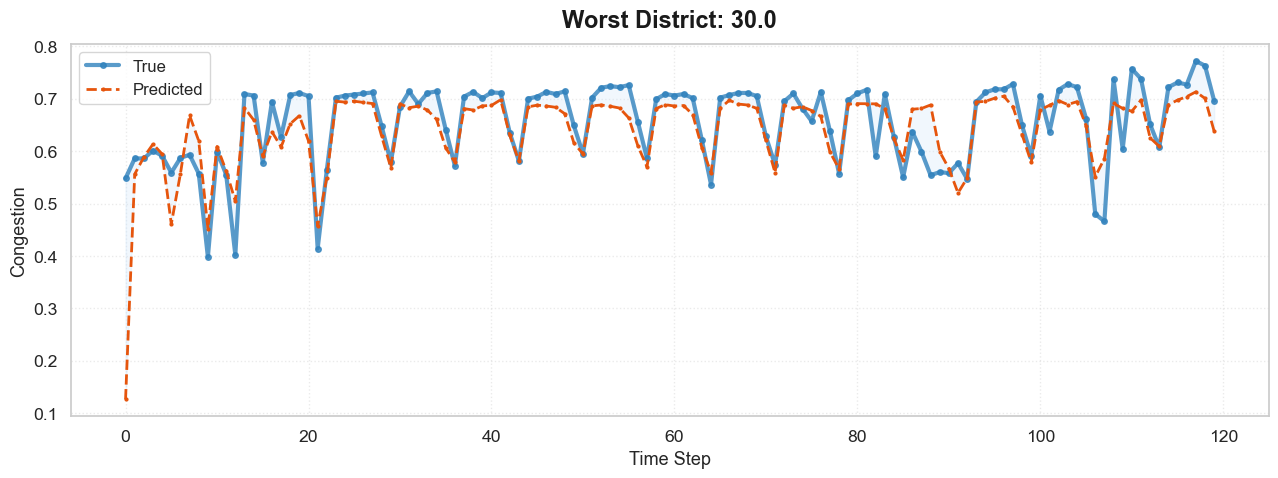

In [8]:
best = sorted_df.iloc[0]["District"]
worst = sorted_df.iloc[-1]["District"]

for name, district in zip(["Best District", "Worst District"], [best, worst]):
    idxs = districts_seq == district
    X_d = Xs_seq[idxs]
    y_d = ys_seq[idxs]
    Xb = torch.tensor(X_d, dtype=torch.float32)
    with torch.no_grad():
        preds = model(Xb).squeeze().numpy()
    preds_inv = sy.inverse_transform(preds.reshape(-1,1))
    y_true_inv = sy.inverse_transform(y_d.reshape(-1,1))
    plt.figure(figsize=(13, 5))
    plt.plot(y_true_inv[:120], label="True", linewidth=3, color="#3182bd", alpha=0.8, marker="o", markersize=4)
    plt.plot(preds_inv[:120], label="Predicted", linewidth=2, color="#e6550d", linestyle="--", marker=".", markersize=4)
    plt.fill_between(range(120), y_true_inv[:120].flatten(), preds_inv[:120].flatten(), color="#d1e6fa", alpha=0.3)
    plt.title(f"{name}: {district}", fontsize=17, weight="bold", color="#1a1a1a", pad=12)
    plt.xlabel("Time Step", fontsize=13)
    plt.ylabel("Congestion", fontsize=13)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [10]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [20]:
max(y_true_inv)

array([0.772])

In [12]:
df = pd.read_csv("data/all_data_merged.csv")  
df["DATE"] = pd.to_datetime(df["DATE"])
target_col = "CONGESTION"  
input_seq_length = 10

Epoch  0: train loss=0.57790
Epoch  5: train loss=0.14082
Epoch 10: train loss=0.06553
Epoch 15: train loss=0.05822
        DATE    weekday  predicted_value
0 2025-01-01  Wednesday         0.495243
1 2025-01-02   Thursday         0.487601
2 2025-01-03     Friday         0.484184
3 2025-01-04   Saturday         0.481631
4 2025-01-05     Sunday         0.480084
En çok congestion: 0.50 - 2025-01-01 00:00:00 (Wednesday)
En az congestion: 0.48 - 2025-01-22 00:00:00 (Wednesday)


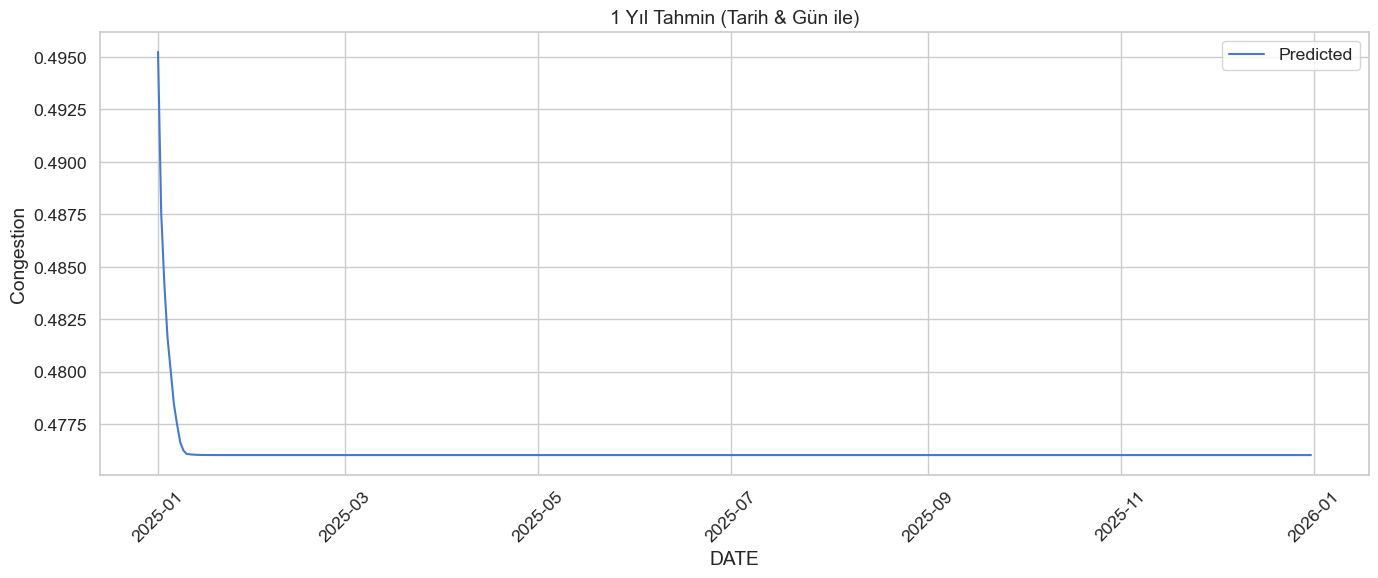

In [ ]:
features = [c for c in df.columns if c not in ["DATE", target_col]]
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_all = scaler_x.fit_transform(df[features])
y_all = scaler_y.fit_transform(df[[target_col]])

Xs, ys, date_targets = [], [], []
for i in range(len(df) - input_seq_length):
    Xs.append(X_all[i:i+input_seq_length])
    ys.append(y_all[i+input_seq_length])
    date_targets.append(df["DATE"].iloc[i+input_seq_length])

Xs = np.array(Xs)
ys = np.array(ys).reshape(-1)

split_idx = int(0.85 * len(Xs))
X_train, X_test = Xs[:split_idx], Xs[split_idx:]
y_train, y_test = ys[:split_idx], ys[split_idx:]
date_test = date_targets[split_idx:]

class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.out(lstm_out[:, -1])
        return out.squeeze(-1)

model = LSTMRegressor(input_dim=Xs.shape[2])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

n_epochs = 20
for epoch in range(n_epochs):
    model.train()
    Xb = torch.tensor(X_train, dtype=torch.float32)
    yb = torch.tensor(y_train, dtype=torch.float32)
    optimizer.zero_grad()
    pred = model(Xb)
    loss = criterion(pred, yb)
    loss.backward()
    optimizer.step()
    if epoch % 5 == 0:
        print(f"Epoch {epoch:2d}: train loss={loss.item():.5f}")

last_date = df["DATE"].iloc[-1]
cur_seq = X_all[-input_seq_length:].copy()
future_dates, future_preds = [], []

for i in range(365):
    next_date = last_date + timedelta(days=i+1)
    next_feat = cur_seq[-1].copy()
    X_in = np.vstack([cur_seq[1:], next_feat])
    X_tensor = torch.tensor(X_in, dtype=torch.float32).unsqueeze(0)
    model.eval()
    with torch.no_grad():
        pred_scaled = model(X_tensor).cpu().numpy()
        pred_val = scaler_y.inverse_transform(pred_scaled.reshape(-1,1)).flatten()[0]
    future_dates.append(next_date)
    future_preds.append(pred_val)
    next_feat[0] = pred_scaled.flatten()[0]
    cur_seq = np.vstack([cur_seq[1:], next_feat])

forecast_df = pd.DataFrame({
    "DATE": future_dates,
    "weekday": [d.strftime("%A") for d in future_dates],
    "predicted_value": future_preds
})
print(forecast_df.head())

max_idx = forecast_df["predicted_value"].idxmax()
max_row = forecast_df.iloc[max_idx]
print(f"Highest congestion: {max_row['predicted_value']:.2f} - {max_row['DATE']} ({max_row['weekday']})")

min_idx = forecast_df["predicted_value"].idxmin()
min_row = forecast_df.iloc[min_idx]
print(f"Lowest congestion: {min_row['predicted_value']:.2f} - {min_row['DATE']} ({min_row['weekday']})")

plt.figure(figsize=(14,6))
plt.plot(forecast_df["DATE"], forecast_df["predicted_value"], label="Predicted")
plt.title("1 Year Forecast")
plt.ylabel("Congestion")
plt.xlabel("DATE")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()